# Wireless Autoencoder (7,4) — PyTorch reimplementacija (Faza 4)

MiSKS projekat, FTN UNS. Reimplementacija MATLAB primera
[Autoencoders for Wireless Communications](https://www.mathworks.com/help/comm/ug/autoencoders-for-wireless-communications.html).


In [ ]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from scipy.special import erfc

# Reproducibilnost
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Koristim: {device}')

Koristim: cuda


## 1. Model

Arhitektura prati MATLAB primer jedan-na-jedan:

```
ENCODER:  one-hot(M) -> FC(M) -> ReLU -> FC(n) -> Energy norm (||x||^2 = n)
KANAL:    AWGN, sigma^2 = 1/(2*R*EbNo_lin) po realnoj komponenti
DECODER:  FC(M) -> ReLU -> FC(M) -> logiti (CrossEntropyLoss radi log_softmax interno)
```

Sa `||x||^2 = n` prosečna snaga po realnoj komponenti je 1, pa je odnos
Eb/No tačan: `Eb = n/k * E_komp = 1/R`, `No = 2*sigma^2 = 1/(R*EbNo)`.

In [ ]:
class AWGNChannel(nn.Module):
    """AWGN kanal kao fiksni (diferencijabilni) sloj.

    Sum po realnoj dimenziji: sigma^2 = 1 / (2 * R * EbNo_lin).
    Konzistentno sa MATLAB lancem EbNoChannel = EbNo + 10*log10(R)
    uz signal prosecne snage 1 po komponenti.
    """
    def __init__(self, k: int, n: int, train_ebno_db: float = 3.0):
        super().__init__()
        self.k, self.n = k, n
        self.train_ebno_db = train_ebno_db

    def forward(self, x: torch.Tensor, ebno_db: float | None = None) -> torch.Tensor:
        if ebno_db is None:
            ebno_db = self.train_ebno_db
        R = self.k / self.n
        ebno_lin = 10.0 ** (ebno_db / 10.0)
        sigma = (1.0 / (2.0 * R * ebno_lin)) ** 0.5
        return x + torch.randn_like(x) * sigma


class Encoder(nn.Module):
    """Tx: one-hot (M) -> n REALNIH vrednosti (kao MATLAB, NE 2n!).

    Energy normalizacija PO UZORKU: ||x||^2 = n.
    Ekvivalent MATLAB helperAEWNormalizationLayer("Energy").
    """
    def __init__(self, M: int, n: int):
        super().__init__()
        self.n = n
        self.net = nn.Sequential(
            nn.Linear(M, M),
            nn.ReLU(),
            nn.Linear(M, n),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        out = self.net(x)
        norm = torch.linalg.vector_norm(out, dim=1, keepdim=True)
        return out * (self.n ** 0.5) / (norm + 1e-8)


class Decoder(nn.Module):
    """Rx: n realnih vrednosti -> logiti za M poruka."""
    def __init__(self, M: int, n: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n, M),
            nn.ReLU(),
            nn.Linear(M, M),  # bez softmax-a
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


class WirelessAutoencoder(nn.Module):
    def __init__(self, k: int = 4, n: int = 7, train_ebno_db: float = 3.0):
        super().__init__()
        self.k, self.n = k, n
        self.M = 2 ** k
        self.encoder = Encoder(self.M, n)
        self.channel = AWGNChannel(k, n, train_ebno_db)
        self.decoder = Decoder(self.M, n)

    def forward(self, x: torch.Tensor, ebno_db: float | None = None,
                channel: nn.Module | None = None) -> torch.Tensor:
        encoded = self.encoder(x)
        chan = channel if channel is not None else self.channel
        received = chan(encoded, ebno_db)
        return self.decoder(received)

    def get_codewords(self) -> np.ndarray:
        """Naucene kodne reci (M, n) za sve poruke."""
        identity = torch.eye(self.M, device=next(self.parameters()).device)
        with torch.no_grad():
            return self.encoder(identity).cpu().numpy()

## 2. Trening

MATLAB referenca: Adam, 10 epoha, minibatch 100·M = 1600, lr 0.08 sa piecewise
padom ×0.1 svakih 5 epoha. Ovde koristimo blaži lr i više iteracija
(mreža je sićušna pa je trening svakako brz), plus `ReduceLROnPlateau`.

Epoha   5/30 | loss 0.1108 | lr 0.01000
Epoha  10/30 | loss 0.0998 | lr 0.01000
Epoha  15/30 | loss 0.0981 | lr 0.01000
Epoha  20/30 | loss 0.0986 | lr 0.01000
Epoha  25/30 | loss 0.0937 | lr 0.00500
Epoha  30/30 | loss 0.0953 | lr 0.00500


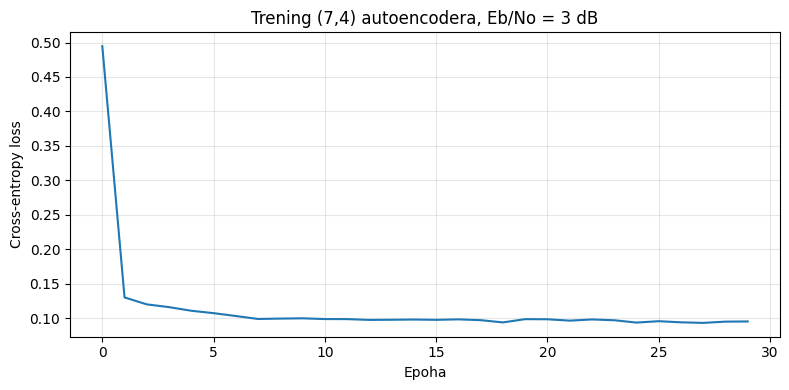

In [ ]:
def one_hot_batch(M: int, batch_size: int, device: torch.device):
    messages = torch.randint(0, M, (batch_size,), device=device)
    oh = torch.zeros(batch_size, M, device=device)
    oh.scatter_(1, messages.unsqueeze(1), 1.0)
    return oh, messages


def train_autoencoder(model: WirelessAutoencoder, num_epochs: int = 30,
                      batches_per_epoch: int = 200, batch_size: int = 1024,
                      lr: float = 0.01) -> list[float]:
    model.train()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=4)
    criterion = nn.CrossEntropyLoss()
    dev = next(model.parameters()).device

    losses: list[float] = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for _ in range(batches_per_epoch):
            oh, messages = one_hot_batch(model.M, batch_size, dev)
            optimizer.zero_grad()
            loss = criterion(model(oh), messages)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()

        avg = epoch_loss / batches_per_epoch
        losses.append(avg)
        scheduler.step(avg)
        if (epoch + 1) % 5 == 0:
            cur_lr = optimizer.param_groups[0]['lr']
            print(f'Epoha {epoch + 1:3d}/{num_epochs} | loss {avg:.4f} | lr {cur_lr:.5f}')
    return losses


model = WirelessAutoencoder(k=4, n=7, train_ebno_db=3.0).to(device)
losses = train_autoencoder(model)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.grid(alpha=0.3)
plt.xlabel('Epoha')
plt.ylabel('Cross-entropy loss')
plt.title('Trening (7,4) autoencodera, Eb/No = 3 dB')
plt.tight_layout()
plt.savefig('training_loss.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Evaluacija: BLER (primarno) + BER (bonus)

**BLER** broji pogresne poruke (`d != dHat`), identicno MATLAB primeru, pa su
krive direktno uporedive. **BER** je bonus: indeks poruke se mapira u k bita
(prirodno binarno) pa se broje bit greske.

In [ ]:
def bits_table(M: int, k: int, device: torch.device) -> torch.Tensor:
    """Lookup tabela (M, k): prirodno binarno mapiranje indeksa u bite."""
    table = [[(i >> b) & 1 for b in range(k - 1, -1, -1)] for i in range(M)]
    return torch.tensor(table, dtype=torch.float32, device=device)


@torch.no_grad()
def evaluate_bler_ber(model: WirelessAutoencoder, ebno_db_vec,
                      num_samples: int = 200_000, batch_size: int = 10_000,
                      channel: nn.Module | None = None,
                      verbose: bool = True):
    model.eval()
    dev = next(model.parameters()).device
    btab = bits_table(model.M, model.k, dev)

    bler, ber = [], []
    for ebno_db in ebno_db_vec:
        blk_err, bit_err, total = 0, 0, 0
        for _ in range(num_samples // batch_size):
            oh, messages = one_hot_batch(model.M, batch_size, dev)
            logits = model(oh, ebno_db=float(ebno_db), channel=channel)
            pred = torch.argmax(logits, dim=1)

            blk_err += (pred != messages).sum().item()
            bit_err += (btab[messages] != btab[pred]).sum().item()
            total += batch_size

        bler.append(blk_err / total)
        ber.append(bit_err / (total * model.k))
        if verbose:
            print(f'Eb/No = {ebno_db:5.1f} dB | BLER = {bler[-1]:.5f} | BER = {ber[-1]:.5f}')
    return np.array(bler), np.array(ber)


ebno_range = np.arange(0.0, 8.5, 0.5)  # MATLAB: simParams.EbNoVec = 0:0.5:8
bler_ae, ber_ae = evaluate_bler_ber(model, ebno_range)

Eb/No =   0.0 dB | BLER = 0.18291 | BER = 0.10193
Eb/No =   0.5 dB | BLER = 0.14911 | BER = 0.08309
Eb/No =   1.0 dB | BLER = 0.11665 | BER = 0.06496
Eb/No =   1.5 dB | BLER = 0.08987 | BER = 0.05048
Eb/No =   2.0 dB | BLER = 0.06680 | BER = 0.03744
Eb/No =   2.5 dB | BLER = 0.04649 | BER = 0.02610
Eb/No =   3.0 dB | BLER = 0.03112 | BER = 0.01739
Eb/No =   3.5 dB | BLER = 0.02056 | BER = 0.01161
Eb/No =   4.0 dB | BLER = 0.01289 | BER = 0.00737
Eb/No =   4.5 dB | BLER = 0.00727 | BER = 0.00409
Eb/No =   5.0 dB | BLER = 0.00399 | BER = 0.00229
Eb/No =   5.5 dB | BLER = 0.00202 | BER = 0.00119
Eb/No =   6.0 dB | BLER = 0.00101 | BER = 0.00057
Eb/No =   6.5 dB | BLER = 0.00038 | BER = 0.00023
Eb/No =   7.0 dB | BLER = 0.00014 | BER = 0.00007
Eb/No =   7.5 dB | BLER = 0.00004 | BER = 0.00002
Eb/No =   8.0 dB | BLER = 0.00002 | BER = 0.00001


## 4. Baseline sistemi

Iste 4 krive kao MATLAB grafik:
1. **Uncoded (4,4) QPSK** — teorijski: `BLER = 1 - (1 - Q(sqrt(2*EbNo)))^4`
2. **Hamming(7,4) + HDD** — simulacija sa sindromskim dekodiranjem
3. **Hamming(7,4) + MLD** — simulacija sa minimum-distance dekodiranjem
4. **Autoencoder (7,4)** — izmereno gore

QPSK = dva nezavisna BPSK po kvadraturama, pa Hamming simuliramo kao BPSK po
kodnom bitu sa `sigma^2 = 1/(2*R*EbNo)`; BLER je identican QPSK slucaju.

In [ ]:
def q_func(x):
    return 0.5 * erfc(x / np.sqrt(2.0))


def bler_uncoded_qpsk(ebno_db_vec, k: int = 4) -> np.ndarray:
    ebno = 10.0 ** (np.asarray(ebno_db_vec) / 10.0)
    ber = q_func(np.sqrt(2.0 * ebno))
    return 1.0 - (1.0 - ber) ** k


# Hamming(7,4), sistematski oblik: G = [I4 | P], H = [P^T | I3]
P = np.array([[1, 1, 0],
              [1, 0, 1],
              [0, 1, 1],
              [1, 1, 1]], dtype=np.int64)
G = np.hstack([np.eye(4, dtype=np.int64), P])          # (4, 7)
H = np.hstack([P.T, np.eye(3, dtype=np.int64)])        # (3, 7)

MESSAGES_4BIT = np.array([[(i >> b) & 1 for b in range(3, -1, -1)]
                          for i in range(16)], dtype=np.int64)      # (16, 4)
CODEBOOK = (MESSAGES_4BIT @ G) % 2                                   # (16, 7)
CODEBOOK_BPSK = 1.0 - 2.0 * CODEBOOK                                 # (16, 7)

# Sindrom -> pozicija bita za flip (HDD ispravlja 1 gresku)
SYNDROME_TO_POS = {}
for pos in range(7):
    e = np.zeros(7, dtype=np.int64)
    e[pos] = 1
    s = tuple((H @ e) % 2)
    SYNDROME_TO_POS[s] = pos


def simulate_hamming74(ebno_db_vec, decoding: str = 'ml',
                       num_blocks: int = 200_000, batch: int = 20_000,
                       rng: np.random.Generator | None = None) -> np.ndarray:
    """BLER za Hamming(7,4) + QPSK, decoding u {'ml', 'hard'}."""
    rng = rng or np.random.default_rng(SEED)
    R = 4.0 / 7.0
    bler = np.zeros(len(ebno_db_vec))

    for i, ebno_db in enumerate(ebno_db_vec):
        sigma = np.sqrt(1.0 / (2.0 * R * 10.0 ** (ebno_db / 10.0)))
        errors, total = 0, 0
        for _ in range(num_blocks // batch):
            msg = rng.integers(0, 16, size=batch)
            tx = CODEBOOK_BPSK[msg]                       # (batch, 7)
            y = tx + rng.normal(0.0, sigma, size=tx.shape)

            if decoding == 'ml':
                # Minimum Euclidean distance nad 16 kodnih reci
                d2 = ((y[:, None, :] - CODEBOOK_BPSK[None, :, :]) ** 2).sum(axis=2)
                msg_hat = d2.argmin(axis=1)
            else:
                hard = (y < 0).astype(np.int64)           # BPSK odluka po bitu
                syndromes = (hard @ H.T) % 2
                for j in range(batch):
                    s = tuple(syndromes[j])
                    if s in SYNDROME_TO_POS:
                        hard[j, SYNDROME_TO_POS[s]] ^= 1
                # Sistematski kod: informacioni biti su prva 4
                info = hard[:, :4]
                msg_hat = info @ (1 << np.arange(3, -1, -1))

            errors += int((msg_hat != msg).sum())
            total += batch
        bler[i] = errors / total
        print(f'Hamming {decoding.upper():4s} | Eb/No = {ebno_db:5.1f} dB | BLER = {bler[i]:.5f}')
    return bler


bler_qpsk = bler_uncoded_qpsk(ebno_range)
bler_ham_ml = simulate_hamming74(ebno_range, decoding='ml')
bler_ham_hd = simulate_hamming74(ebno_range, decoding='hard')

Hamming ML   | Eb/No =   0.0 dB | BLER = 0.17867
Hamming ML   | Eb/No =   0.5 dB | BLER = 0.14502
Hamming ML   | Eb/No =   1.0 dB | BLER = 0.11403
Hamming ML   | Eb/No =   1.5 dB | BLER = 0.08651
Hamming ML   | Eb/No =   2.0 dB | BLER = 0.06308
Hamming ML   | Eb/No =   2.5 dB | BLER = 0.04489
Hamming ML   | Eb/No =   3.0 dB | BLER = 0.03023
Hamming ML   | Eb/No =   3.5 dB | BLER = 0.01969
Hamming ML   | Eb/No =   4.0 dB | BLER = 0.01173
Hamming ML   | Eb/No =   4.5 dB | BLER = 0.00685
Hamming ML   | Eb/No =   5.0 dB | BLER = 0.00351
Hamming ML   | Eb/No =   5.5 dB | BLER = 0.00168
Hamming ML   | Eb/No =   6.0 dB | BLER = 0.00079
Hamming ML   | Eb/No =   6.5 dB | BLER = 0.00034
Hamming ML   | Eb/No =   7.0 dB | BLER = 0.00012
Hamming ML   | Eb/No =   7.5 dB | BLER = 0.00003
Hamming ML   | Eb/No =   8.0 dB | BLER = 0.00001
Hamming HARD | Eb/No =   0.0 dB | BLER = 0.26200
Hamming HARD | Eb/No =   0.5 dB | BLER = 0.22388
Hamming HARD | Eb/No =   1.0 dB | BLER = 0.18740
Hamming HARD | Eb/No

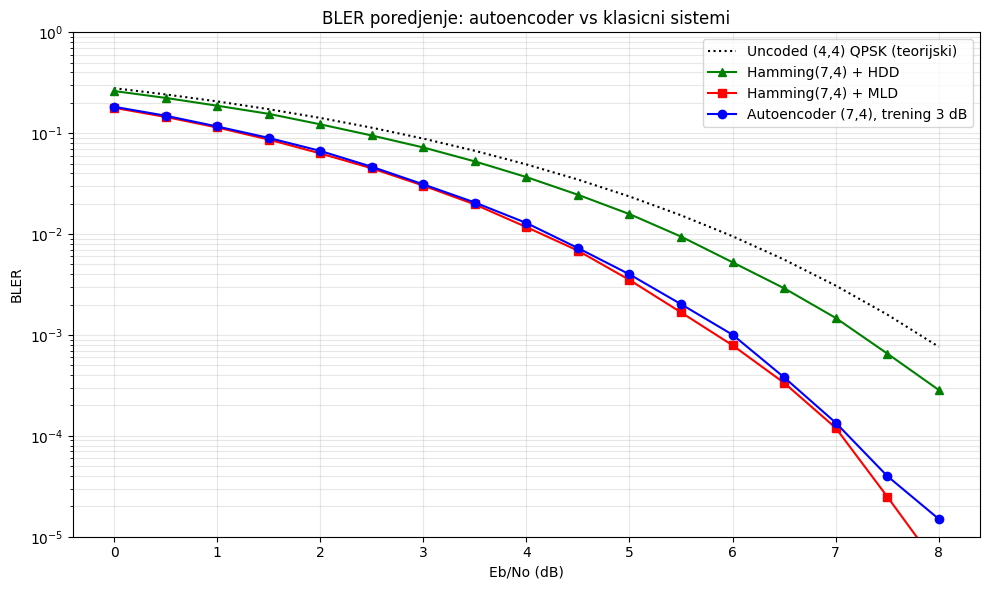

In [ ]:
plt.figure(figsize=(10, 6))
plt.semilogy(ebno_range, bler_qpsk, 'k:',  label='Uncoded (4,4) QPSK (teorijski)')
plt.semilogy(ebno_range, bler_ham_hd, 'g-^', label='Hamming(7,4) + HDD')
plt.semilogy(ebno_range, bler_ham_ml, 'r-s', label='Hamming(7,4) + MLD')
plt.semilogy(ebno_range, bler_ae, 'b-o', label='Autoencoder (7,4), trening 3 dB')
plt.grid(True, which='both', alpha=0.3)
plt.ylim(1e-5, 1)
plt.xlabel('Eb/No (dB)')
plt.ylabel('BLER')
plt.title('BLER poredjenje: autoencoder vs klasicni sistemi')
plt.legend()
plt.tight_layout()
plt.savefig('bler_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Ocekivanje (MATLAB docs): AE ~ MLD Hamming; HDD ~0.6 dB nad uncoded;
# MLD jos ~1.5 dB; coding gain AE ~2 dB nad uncoded.

## 5. Naučena konstelacija

Kodne reči žive u 7D prostoru, pa za 2D prikaz koristimo PCA (MATLAB koristi
t-SNE za k>2; PCA je deterministička i čuva globalne udaljenosti, što je za
ovu svrhu čak i bolje). Dodatno računamo minimalnu međusobnu distancu i
poredimo sa Hamming(7,4) BPSK kodom.

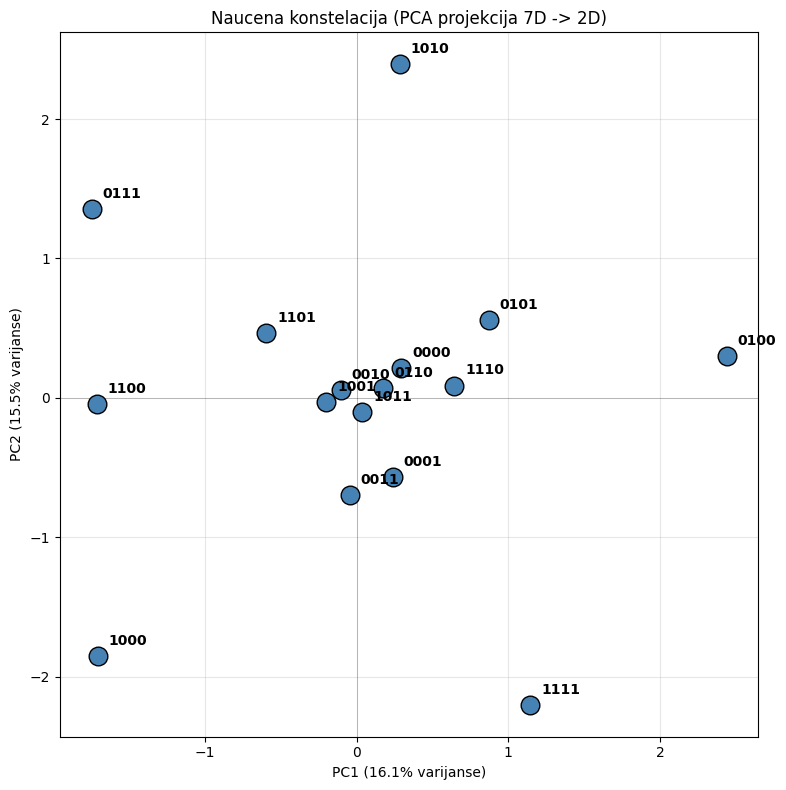

d_min autoencoder:   3.282
d_min Hamming BPSK:  3.464  (d_min^2 = 4*d_H_min = 12, d_min = 3.464)


In [ ]:
from sklearn.decomposition import PCA


def plot_constellation_pca(model: WirelessAutoencoder,
                           save_path: str = 'constellation_pca.png'):
    cw = model.get_codewords()                       # (M, n)
    pca = PCA(n_components=2)
    pts = pca.fit_transform(cw)
    ev = pca.explained_variance_ratio_

    plt.figure(figsize=(8, 8))
    for i in range(model.M):
        plt.scatter(*pts[i], s=180, c='steelblue', edgecolors='black', zorder=3)
        bits = format(i, f'0{model.k}b')
        plt.annotate(bits, pts[i], textcoords='offset points',
                     xytext=(8, 8), fontsize=10, fontweight='bold')
    plt.axhline(0, color='k', lw=0.5, alpha=0.3)
    plt.axvline(0, color='k', lw=0.5, alpha=0.3)
    plt.grid(alpha=0.3)
    plt.xlabel(f'PC1 ({ev[0] * 100:.1f}% varijanse)')
    plt.ylabel(f'PC2 ({ev[1] * 100:.1f}% varijanse)')
    plt.title('Naucena konstelacija (PCA projekcija 7D -> 2D)')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    return cw


codewords = plot_constellation_pca(model)

# Minimalna Euklidska distanca naucenog koda vs Hamming(7,4) BPSK
def min_pairwise_dist(cw: np.ndarray) -> float:
    d = np.linalg.norm(cw[:, None, :] - cw[None, :, :], axis=2)
    return d[~np.eye(len(cw), dtype=bool)].min()

d_ae = min_pairwise_dist(codewords)
d_ham = min_pairwise_dist(CODEBOOK_BPSK * np.sqrt(7.0 / 7.0))
print(f'd_min autoencoder:   {d_ae:.3f}')
print(f'd_min Hamming BPSK:  {d_ham:.3f}  (d_min^2 = 4*d_H_min = 12, d_min = 3.464)')

## 6. Poređenje sa MATLAB rezultatima

Iz MATLAB-a eksportuj `[EbNoVec; BLER]` kao CSV (kolone: `ebno_db,bler`), upload
u Colab i pokreni ćeliju. Odstupanja do ~0.5 dB su normalna (drugačija
inicijalizacija i seed).

In [ ]:
import os

MATLAB_CSV = '/content/matlab_bler.csv'
if os.path.exists(MATLAB_CSV):
    m = np.loadtxt(MATLAB_CSV, delimiter=',', skiprows=1)
    plt.figure(figsize=(10, 6))
    plt.semilogy(ebno_range, bler_ae, 'b-o', label='PyTorch AE (7,4)')
    plt.semilogy(m[:, 0], m[:, 1], 'r--s', label='MATLAB AE (7,4)')
    plt.grid(True, which='both', alpha=0.3)
    plt.xlabel('Eb/No (dB)')
    plt.ylabel('BLER')
    plt.title('Cross-validacija implementacija: PyTorch vs MATLAB')
    plt.legend()
    plt.tight_layout()
    plt.savefig('comparison_matlab_pytorch.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('matlab_bler.csv nije pronadjen, preskacem (uploaduj kad budes imao MATLAB rezultate).')

matlab_bler.csv nije pronadjen, preskacem (uploaduj kad budes imao MATLAB rezultate).


## 7. Čuvanje modela (priprema za Fazu 5, HF Hub)

Token NE hardkodovati — koristi Colab Secrets (ikonica ključa levo, dodaj
`HF_TOKEN`), pa `from google.colab import userdata; login(token=userdata.get('HF_TOKEN'))`.

In [ ]:
torch.save({
    'model_state_dict': model.state_dict(),
    'config': {'k': model.k, 'n': model.n, 'train_ebno_db': 3.0},
    'results': {
        'ebno_db': ebno_range.tolist(),
        'bler': bler_ae.tolist(),
        'ber': ber_ae.tolist(),
    },
}, 'wireless_autoencoder_7_4.pt')
print('Sacuvano: wireless_autoencoder_7_4.pt')

Sacuvano: wireless_autoencoder_7_4.pt


## 8. Bonus: Rayleigh blok-fading (priprema za Fazu 6, Eksperiment 1)

Model: `y = alpha * x + w`, gde je `alpha` Rayleigh amplituda po bloku
(`E[alpha^2] = 1`), uz pretpostavku savršene fazne sinhronizacije i bez
poznavanja `alpha` na prijemu (nema ekvalizacije). Autoencoder treniran na
AWGN se testira **bez retreniranja**, razlika u dB na ciljnom BLER je
kvantifikacija aproksimacije idealnog kanala za slajd 11.

Eb/No =   0.0 dB | BLER = 0.35074 | BER = 0.19253
Eb/No =   0.5 dB | BLER = 0.32630 | BER = 0.17946
Eb/No =   1.0 dB | BLER = 0.30275 | BER = 0.16612
Eb/No =   1.5 dB | BLER = 0.28035 | BER = 0.15382
Eb/No =   2.0 dB | BLER = 0.25580 | BER = 0.14081
Eb/No =   2.5 dB | BLER = 0.23494 | BER = 0.12915
Eb/No =   3.0 dB | BLER = 0.21623 | BER = 0.11874
Eb/No =   3.5 dB | BLER = 0.19901 | BER = 0.10967
Eb/No =   4.0 dB | BLER = 0.17982 | BER = 0.09946
Eb/No =   4.5 dB | BLER = 0.16487 | BER = 0.09088
Eb/No =   5.0 dB | BLER = 0.14925 | BER = 0.08228
Eb/No =   5.5 dB | BLER = 0.13370 | BER = 0.07387
Eb/No =   6.0 dB | BLER = 0.12342 | BER = 0.06812
Eb/No =   6.5 dB | BLER = 0.11131 | BER = 0.06132
Eb/No =   7.0 dB | BLER = 0.10100 | BER = 0.05560
Eb/No =   7.5 dB | BLER = 0.09076 | BER = 0.04999
Eb/No =   8.0 dB | BLER = 0.08149 | BER = 0.04494


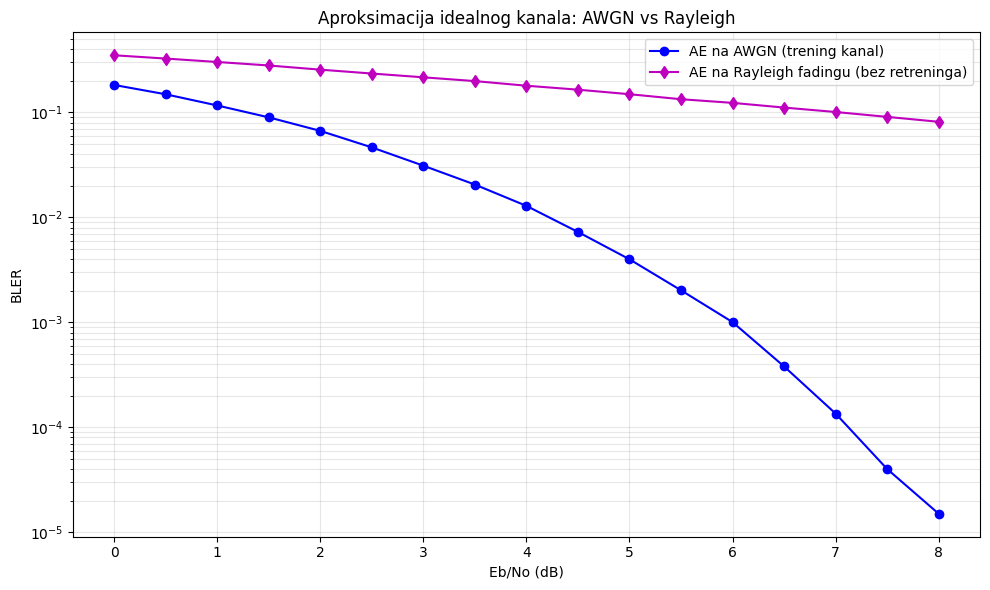

In [ ]:
class RayleighBlockFading(nn.Module):
    """Flat blok Rayleigh fading + AWGN, bez CSI na prijemu.

    alpha = |h|, h ~ CN(0,1) => alpha^2 = hr^2 + hi^2, hr,hi ~ N(0, 0.5).
    """
    def __init__(self, k: int, n: int):
        super().__init__()
        self.k, self.n = k, n

    def forward(self, x: torch.Tensor, ebno_db: float) -> torch.Tensor:
        batch = x.shape[0]
        hr = torch.randn(batch, 1, device=x.device) * (0.5 ** 0.5)
        hi = torch.randn(batch, 1, device=x.device) * (0.5 ** 0.5)
        alpha = torch.sqrt(hr ** 2 + hi ** 2)

        R = self.k / self.n
        sigma = (1.0 / (2.0 * R * 10.0 ** (ebno_db / 10.0))) ** 0.5
        return alpha * x + torch.randn_like(x) * sigma


rayleigh = RayleighBlockFading(k=model.k, n=model.n)
bler_ray, _ = evaluate_bler_ber(model, ebno_range, channel=rayleigh)

plt.figure(figsize=(10, 6))
plt.semilogy(ebno_range, bler_ae, 'b-o', label='AE na AWGN (trening kanal)')
plt.semilogy(ebno_range, bler_ray, 'm-d', label='AE na Rayleigh fadingu (bez retreninga)')
plt.grid(True, which='both', alpha=0.3)
plt.xlabel('Eb/No (dB)')
plt.ylabel('BLER')
plt.title('Aproksimacija idealnog kanala: AWGN vs Rayleigh')
plt.legend()
plt.tight_layout()
plt.savefig('awgn_vs_rayleigh.png', dpi=150, bbox_inches='tight')
plt.show()

# Horizontalna razlika izmedju krivih na istom BLER nivou = X dB za slajd 11.

In [ ]:
from huggingface_hub import HfApi, login
from google.colab import userdata
import os

HF_USERNAME = "nikolabakic"
REPO_ID = f"{HF_USERNAME}/wireless-autoencoder-7-4"

login(token=userdata.get("HF_TOKEN"))
api = HfApi()

# 1. obriši pokvaren repo
api.delete_repo(repo_id=REPO_ID, repo_type="model")

# 2. proveri da su oba fajla lokalno PRE uploada
print("pt    :", os.path.exists("wireless_autoencoder_7_4.pt"),
      os.path.getsize("wireless_autoencoder_7_4.pt"), "B")
print("readme:", os.path.exists("README.md"))

# 3. napravi ponovo i uploaduj oba odjednom (atomično, nema LFS zavrzlame)
api.create_repo(repo_id=REPO_ID, repo_type="model", exist_ok=True)
api.upload_folder(
    folder_path=".",
    repo_id=REPO_ID,
    repo_type="model",
    allow_patterns=["wireless_autoencoder_7_4.pt", "README.md"],
)
print(f"Gotovo: https://huggingface.co/{REPO_ID}")


pt    : True 7995 B
readme: False


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...reless_autoencoder_7_4.pt: 100%|##########| 8.00kB / 8.00kB            

Gotovo: https://huggingface.co/nikolabakic/wireless-autoencoder-7-4
